## Homework 6
Hi everyone this is your sixth homework.

In this exercise, You will deal with **Unsupervised Learning**.

You are free to discuss the problems and ways to approach them with your classmates, but be sure to not cheat. **Cheating will not be tolerated**.

## <font color="red">**Question 1**</font>
In this problem, you will generate simulated data, and then perform
PCA and K-means clustering on the data.

- Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [2]:
# Set seed for reproducibility
np.random.seed(0)

In [3]:
# Write function to generate simulated data
def generate_data():
    # Simulate three classes with different means
    class_1 = np.random.normal(4, 1.5, size=(20, 50))
    class_2 = np.random.normal(5, 1.5, size=(20, 50))
    class_3 = np.random.normal(6, 1.5, size=(20, 50))
    
    # Combine the classes and create labels
    data = np.vstack((class_1, class_2, class_3))
    labels = np.repeat([1, 2, 3], 20)
    
    return data, labels

# Generate simulated data
simulated_data, true_labels = generate_data()

- Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

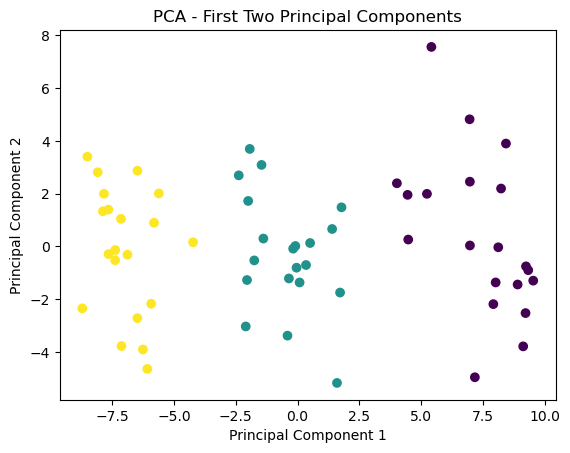

In [4]:
# Perform PCA and plot the first two principal component score vectors
pca = PCA(n_components=2)
pca_result = pca.fit_transform(simulated_data)

# Plot the PCA results with different colors for each class
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=true_labels, cmap='viridis')
plt.title('PCA - First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


- Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels?

In [5]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix, davies_bouldin_score

# Perform K-means clustering with K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=0)
kmeans_labels_3 = kmeans_3.fit_predict(simulated_data)

# Evaluate how well K-means clusters compare to true class labels
ari_3 = adjusted_rand_score(true_labels, kmeans_labels_3)
conf_matrix_3 = confusion_matrix(true_labels, kmeans_labels_3)
davies_bouldin_3 = davies_bouldin_score(simulated_data, kmeans_labels_3)
# Print and display evaluation results

print(f"Adjusted Rand Index (ARI) for K = 3: {ari_3}\n")
print("Confusion Matrix for K = 3:")
print(conf_matrix_3,"\n")
print(f"Davies-Bouldin Index for K = 3: {davies_bouldin_3}")


Adjusted Rand Index (ARI) for K = 3: 1.0

Confusion Matrix for K = 3:
[[ 0  0  0  0]
 [ 0  0 20  0]
 [ 0 20  0  0]
 [20  0  0  0]] 

Davies-Bouldin Index for K = 3: 2.7052147062047616


- Perform K-means clustering with K = 2. Describe your results.

In [6]:

# Perform K-means clustering with K = 2
kmeans_2 = KMeans(n_clusters=2, random_state=0)
kmeans_labels_2 = kmeans_2.fit_predict(simulated_data)

# Evaluate how well K-means clusters compare to true class labels
ari_2 = adjusted_rand_score(true_labels, kmeans_labels_2)
conf_matrix_2 = confusion_matrix(true_labels, kmeans_labels_2)
davies_bouldin_2 = davies_bouldin_score(simulated_data, kmeans_labels_2)

# Print and display evaluation results
print(f"Adjusted Rand Index (ARI) for K = 2: {ari_2}\n")
print("Confusion Matrix for K = 2:")
print(conf_matrix_2,"\n")

print(f"Davies-Bouldin Index for K = 2: {davies_bouldin_2}")

Adjusted Rand Index (ARI) for K = 2: 0.46542680019074867

Confusion Matrix for K = 2:
[[ 0  0  0  0]
 [20  0  0  0]
 [ 5 15  0  0]
 [ 0 20  0  0]] 

Davies-Bouldin Index for K = 2: 1.9393884195942575


- Now perform K-means clustering with K = 4, and describe your results.

In [7]:
# Perform K-means clustering with K = 4
kmeans_4 = KMeans(n_clusters=4, random_state=0)
kmeans_labels_4 = kmeans_4.fit_predict(simulated_data)

# Evaluate how well K-means clusters compare to true class labels
ari_4 = adjusted_rand_score(true_labels, kmeans_labels_4)
conf_matrix_4 = confusion_matrix(true_labels, kmeans_labels_4)
davies_bouldin_4 = davies_bouldin_score(simulated_data, kmeans_labels_4)

# Print and display evaluation results
print(f"Adjusted Rand Index (ARI) for K = 4: {ari_4}\n")
print("Confusion Matrix for K = 4:")
print(conf_matrix_4,"\n")
print(f"Davies-Bouldin Index for K = 2: {davies_bouldin_4}")

Adjusted Rand Index (ARI) for K = 4: 0.8771086543523542

Confusion Matrix for K = 4:
[[ 0  0  0  0]
 [13  0  7  0]
 [ 0  0  0 20]
 [ 0 20  0  0]] 

Davies-Bouldin Index for K = 2: 2.8758605185335453


###
$$\Large\textbf{Result Analysis}$$

####
$$\large\textbf{Visualize the Results}$$

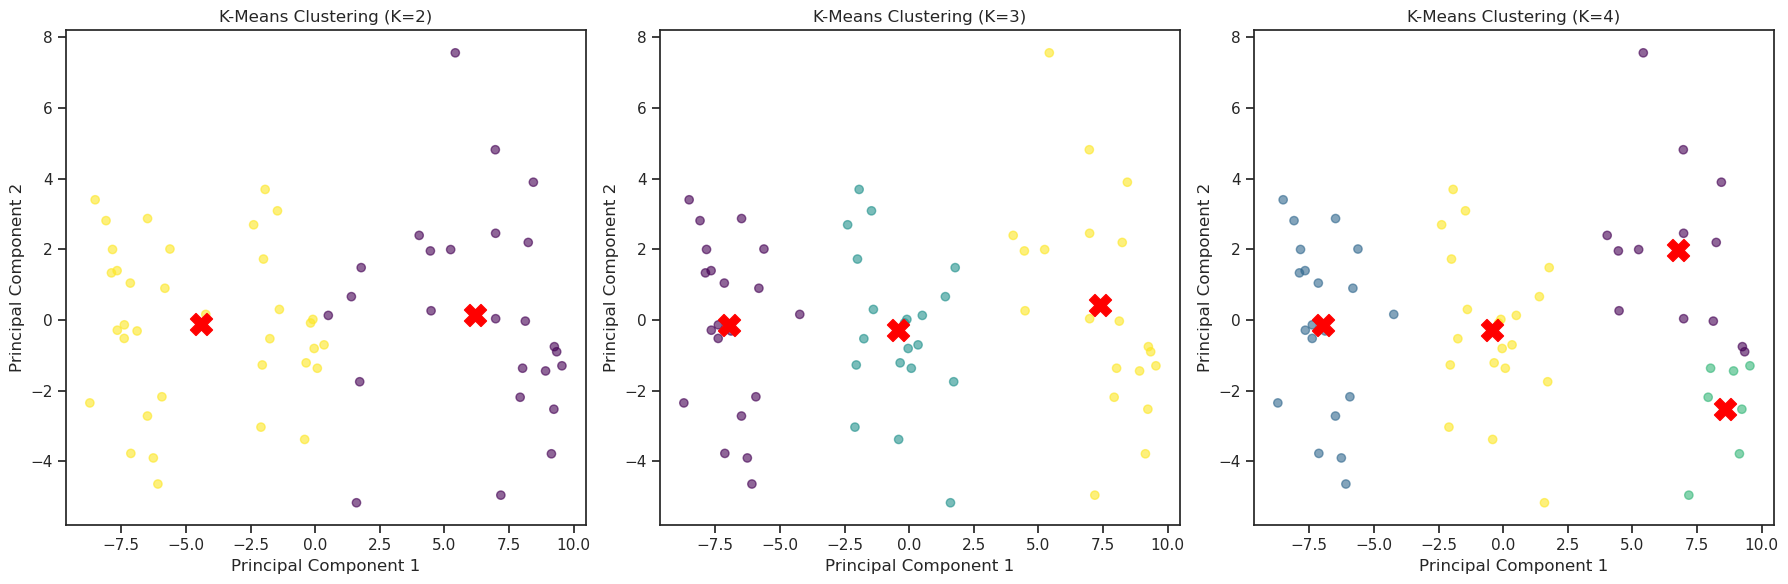

In [83]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Perform PCA on the simulated data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(simulated_data)

# Set up a matplotlib figure with subplots
plt.figure(figsize=(18, 6))

# List to hold titles for subplots
titles = ['K-Means Clustering (K=2)', 'K-Means Clustering (K=3)', 'K-Means Clustering (K=4)']

# Loop over each K value and create subplots
for i, k in enumerate([2, 3, 4], start=1):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans_labels = kmeans.fit_predict(simulated_data)
    
    # Get PCA-transformed coordinates for cluster centers
    centers = pca.transform(kmeans.cluster_centers_)

    # Create subplot
    plt.subplot(1, 3, i)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, marker='X', label='Centroids')
    plt.title(titles[i-1])
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')

# Adjust the spacing between subplots
plt.tight_layout()
plt.show()

####
$$\large\textbf{Analysis of the Metrics}$$

$$\textbf{For K = 4:}$$

`ARI = 0.877` shows high similarity between the K-means clusters and the true labels.

`DBI = 2.8759` is relatively high, which makes sense because the data is pretty sparse.


$$\textbf{For K = 2:}$$

`ARI = 0.4654` is moderate, showing some similarity between the clusters and the true labels.

`DBI = 1.9394`, indicates that the clusters are more compact and better separated than for K = 4.

$$\textbf{For K = 3:}$$

`ARI = 1.0` shows perfect match between the clusters and the true labels.

`DBI = 2.7052`,  which indicates some overlap, and shows that the issue of compactness of clusters, still exist. Which makes sense, becase the initial generated data was not really compact, so there is no concern.


####
$$\large\textbf{Conclusion:}$$


Perfect ARI score shows that `K=3` is the perfect model, even if the DBI isn’t the lowest.

`K = 2` end up in a moderate performance, because it fails to separate the data into the true classes.

`K = 4` ends up in high performance but it over-segments the data into more clusters than there are true classes. The higher DBI suggests that the clusters are not as well separated or compact as they should be.

## <font color="red">**Question 2**</font>

For a real world example, we will use **Bank Marketing Data Set dataset**. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution.

**Columns**
1. age (numeric)
2. job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3. marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4. education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5. default: has credit in default? (categorical: 'no','yes','unknown')
6. housing: has housing loan? (categorical: 'no','yes','unknown')
7. loan: has personal loan? (categorical: 'no','yes','unknown')

**Related with the last contact of the current campaign:**
8. contact: contact communication type (categorical: 'cellular','telephone')
9. month: last contact month of year (categorical: 'jan', 'feb', 'mar', …, 'nov', 'dec')
10. day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11. duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

**Other attributes:**
12. campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13. pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14. previous: number of contacts performed before this campaign and for this client (numeric)
15. poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

**Social and economic context attributes**
16. emp.var.rate: employment variation rate - quarterly indicator (numeric)
17. cons.price.idx: consumer price index - monthly indicator (numeric)
18. cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19. euribor3m: euribor 3 month rate - daily indicator (numeric)
20. nr.employed: number of employees - quarterly indicator (numeric)
21. subscribed : has the client subscribed a term deposit? (binary: 'yes','no')


In [8]:
# Load Libarary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mping
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [9]:
# Load the dataset
df = pd.read_csv("bank_marketing_dataset.csv")


#### Exploratory Data Analysis - Preprocessing

- let's try to undertand age distribution of customers.

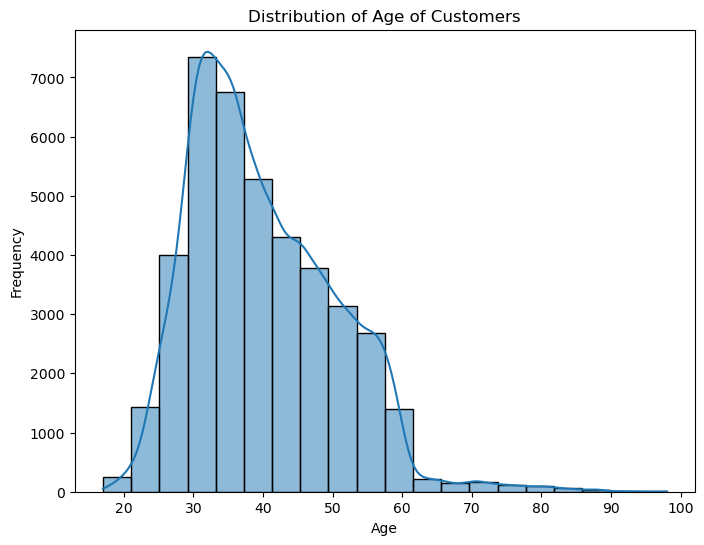

In [10]:
# Understand age distribution of customers
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Age of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


-  see if there is between ages and loan status of customers.

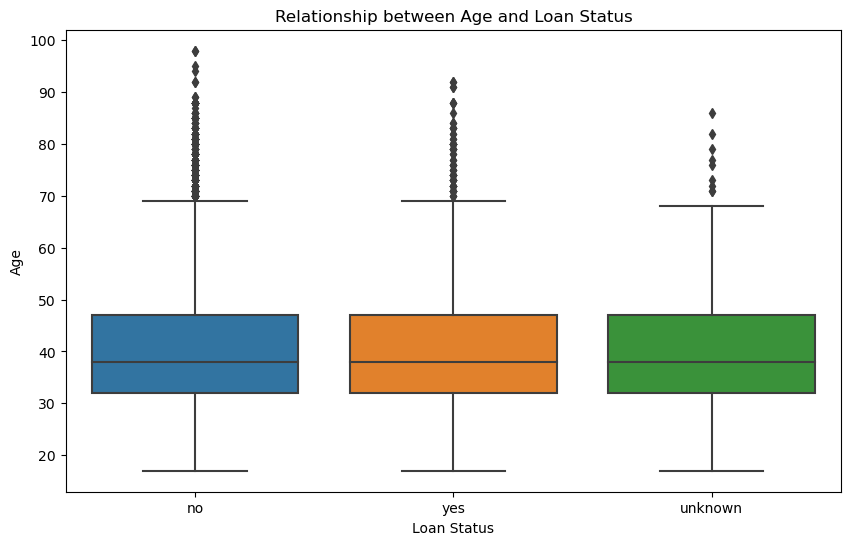

In [11]:
# Check if there is a relationship between ages and loan status of customers
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan', y='age', data=df)
plt.title('Relationship between Age and Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Age')
plt.show()

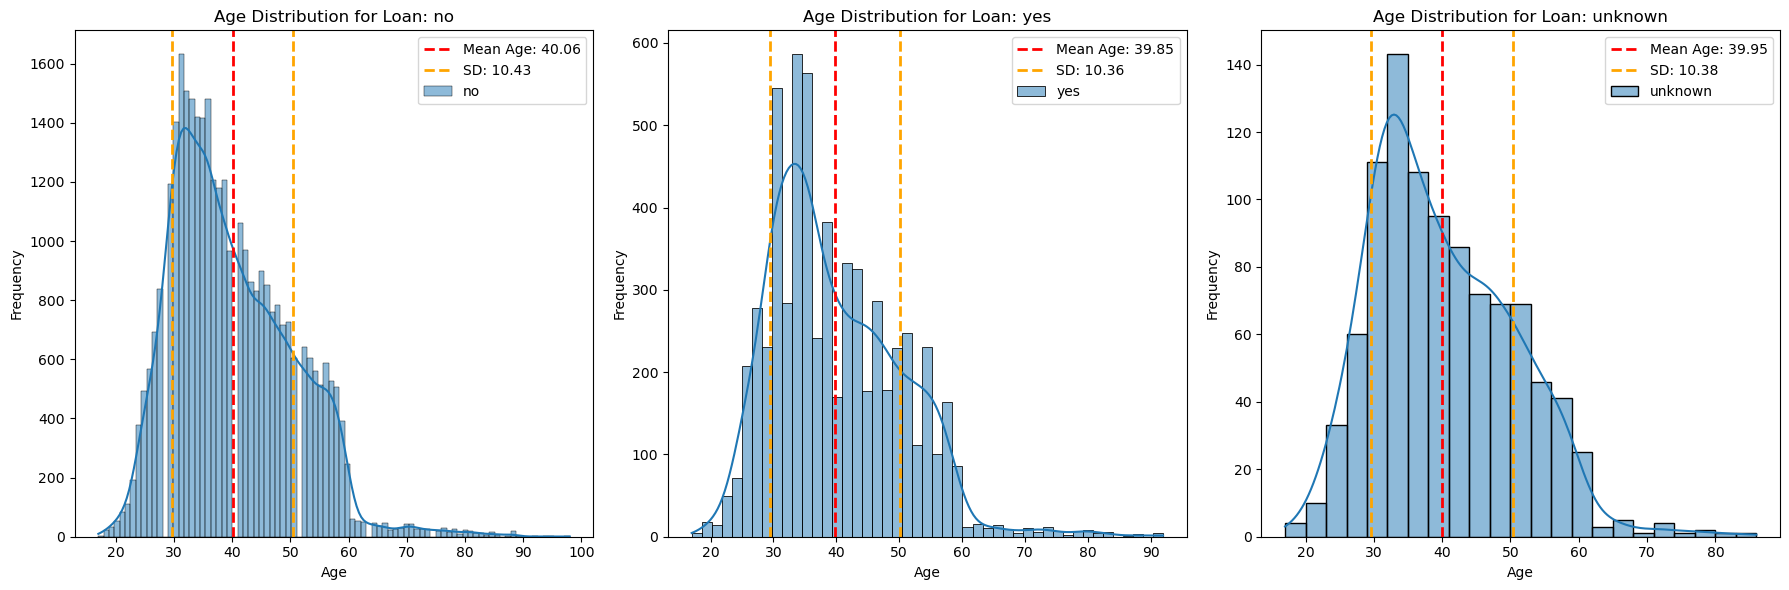

In [12]:
# Create subplots for different categories of Loan
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Plot histograms for each category
for i, loan_category in enumerate(['no', 'yes', 'unknown']):
    sns.histplot(df[df['loan'] == loan_category]['age'], kde=True, ax=axes[i], label=loan_category)
    
    # Plot mean line
    mean_age = df[df['loan'] == loan_category]['age'].mean()
    std_age = df[df['loan'] == loan_category]['age'].std()
    
    axes[i].axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean Age: {mean_age:.2f}')
    axes[i].axvline(mean_age + std_age, color='orange', linestyle='dashed', linewidth=2, label=f'SD: {std_age:.2f}')
    axes[i].axvline(mean_age - std_age, color='orange', linestyle='dashed', linewidth=2)
    
    axes[i].set_title(f'Age Distribution for Loan: {loan_category}')
    axes[i].set_xlabel('Age')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()


- try to undertand marital status distribution of customers.

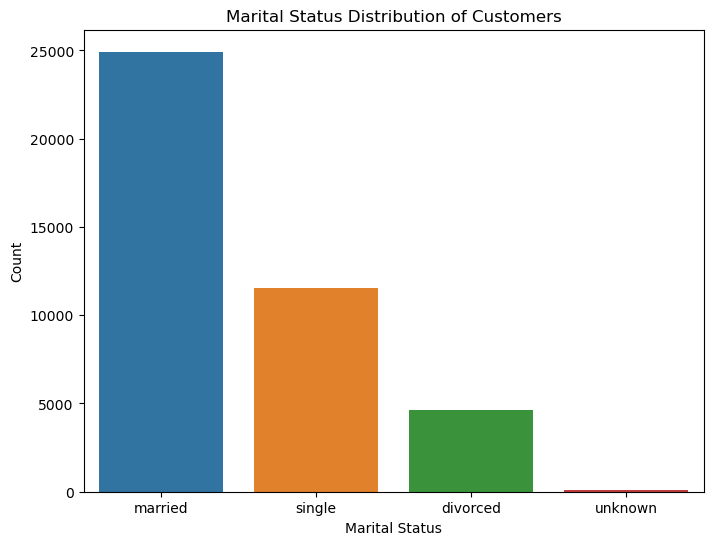

In [13]:
# Understand marital status distribution of customers
plt.figure(figsize=(8, 6))
sns.countplot(x='marital', data=df)
plt.title('Marital Status Distribution of Customers')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()


- pdays column means number of days that passed by after the client was last contacted from a previous campaign. 999 means client was not previously contacted. look at that.

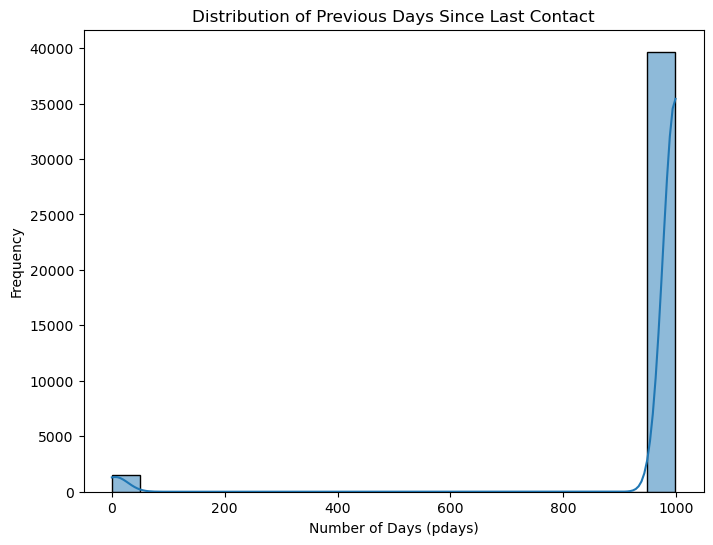

In [14]:
# Analyze pdays column
plt.figure(figsize=(8, 6))
sns.histplot(df['pdays'], bins=20, kde=True)
plt.title('Distribution of Previous Days Since Last Contact')
plt.xlabel('Number of Days (pdays)')
plt.ylabel('Frequency')
plt.show()


- look distribution of durations based on contact type

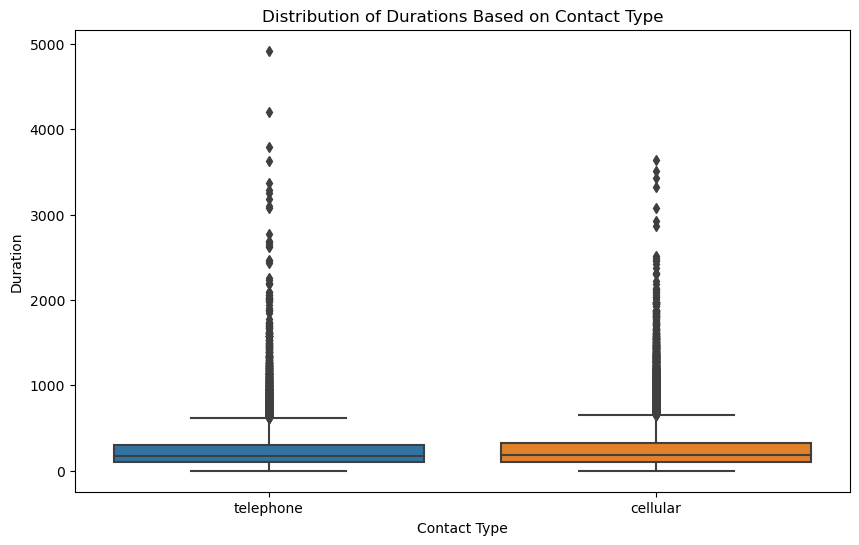

In [15]:
# Look at the distribution of durations based on contact type
plt.figure(figsize=(10, 6))
sns.boxplot(x='contact', y='duration', data=df)
plt.title('Distribution of Durations Based on Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Duration')
plt.show()

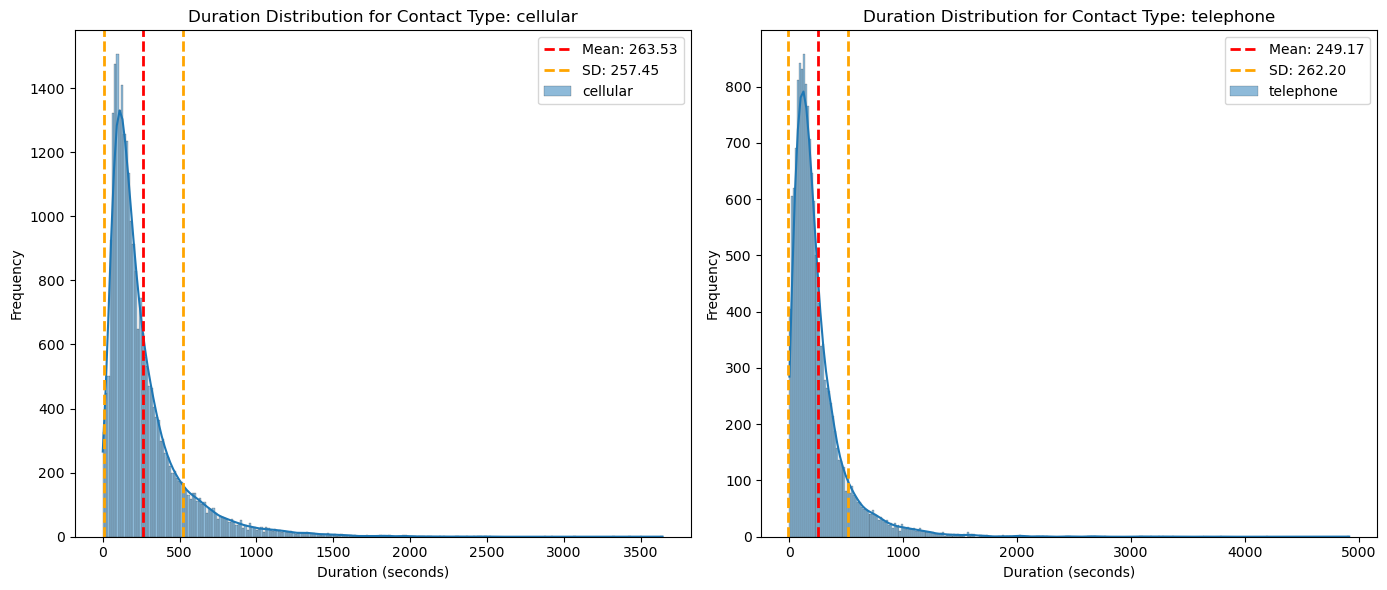

In [16]:
# Create subplots for different categories of Contact
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Plot histograms for each category
for i, contact_type in enumerate(['cellular', 'telephone']):
    sns.histplot(df[df['contact'] == contact_type]['duration'], kde=True, ax=axes[i], label=contact_type)
    
    # Plot mean line
    mean_duration = df[df['contact'] == contact_type]['duration'].mean()
    std_duration = df[df['contact'] == contact_type]['duration'].std()
    
    axes[i].axvline(mean_duration, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_duration:.2f}')
    axes[i].axvline(mean_duration + std_duration, color='orange', linestyle='dashed', linewidth=2, label=f'SD: {std_duration:.2f}')
    axes[i].axvline(mean_duration - std_duration, color='orange', linestyle='dashed', linewidth=2)
    
    axes[i].set_title(f'Duration Distribution for Contact Type: {contact_type}')
    axes[i].set_xlabel('Duration (seconds)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()


- look loan status of customers.

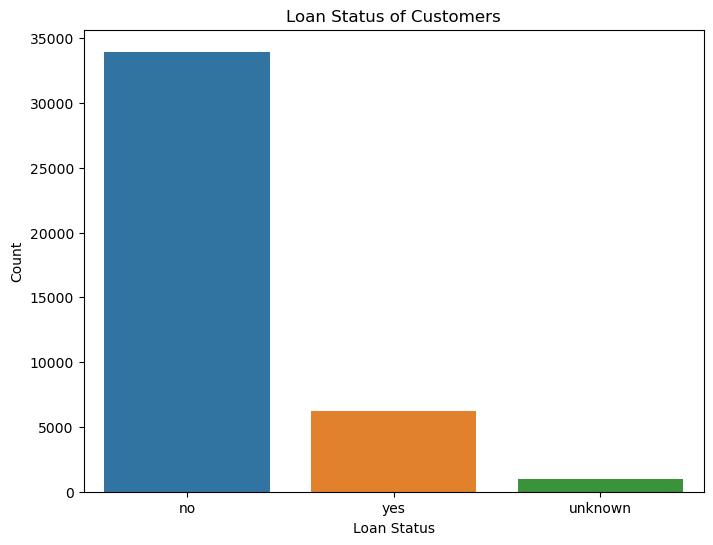

In [17]:
# Look at the loan status of customers
plt.figure(figsize=(8, 6))
sns.countplot(x='loan', data=df)
plt.title('Loan Status of Customers')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()


- look jobs, education customers

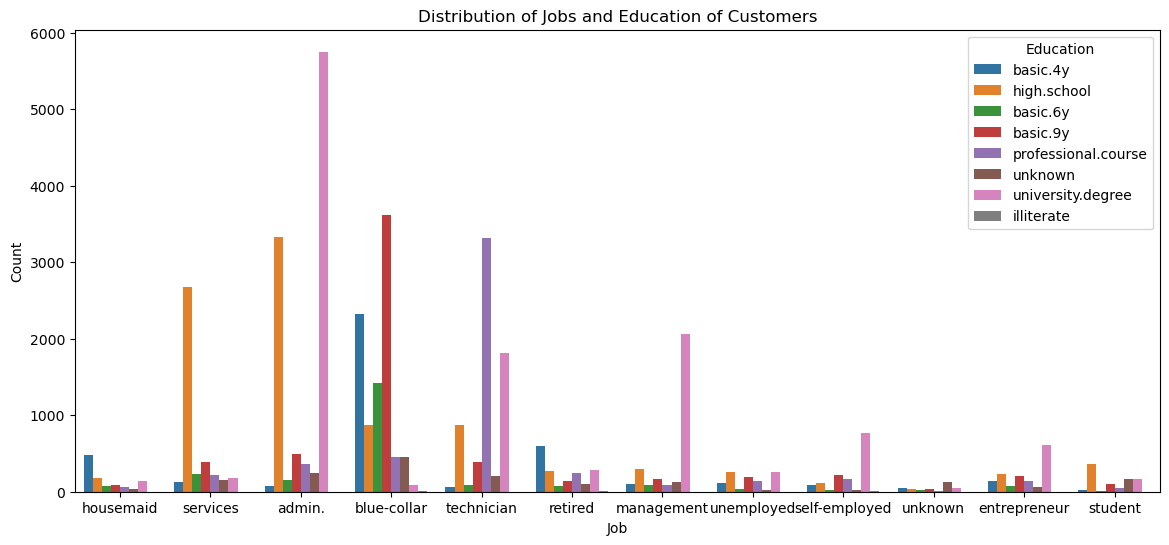

In [18]:
plt.figure(figsize=(14, 6))
sns.countplot(x='job', hue='education', data=df)
plt.title('Distribution of Jobs and Education of Customers')
plt.xlabel('Job')
plt.ylabel('Count')
plt.legend(title='Education')
plt.show()

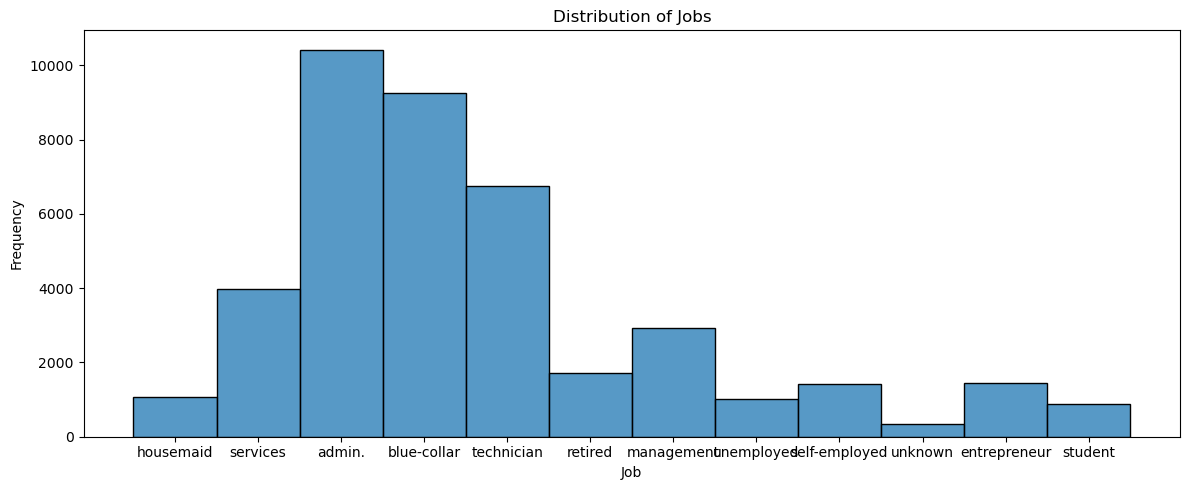

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))

# Plot histograms for Jobs
sns.histplot(df['job'], kde=False, ax=axes)
axes.set_title('Distribution of Jobs')
axes.set_xlabel('Job')
axes.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

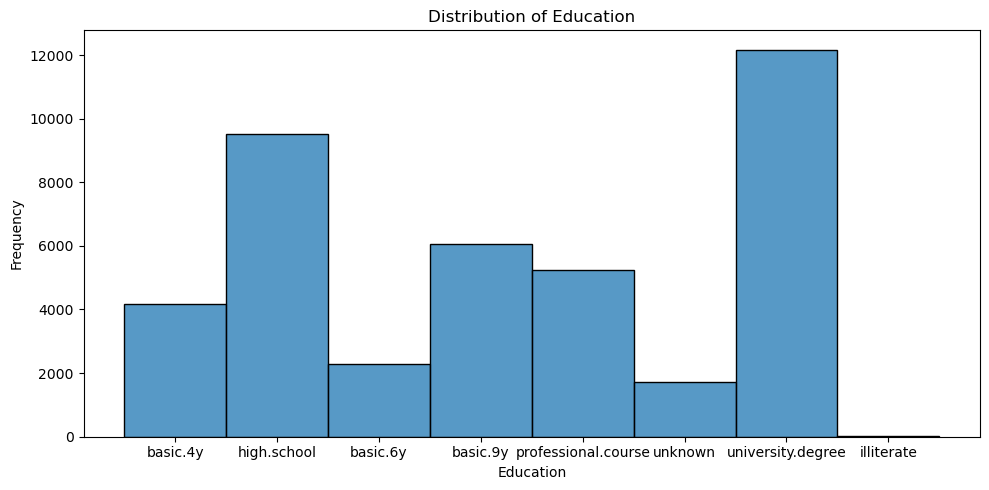

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

# Plot histograms for Education
sns.histplot(df['education'], ax=axes, kde=False)
axes.set_title('Distribution of Education')
axes.set_xlabel('Education')
axes.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

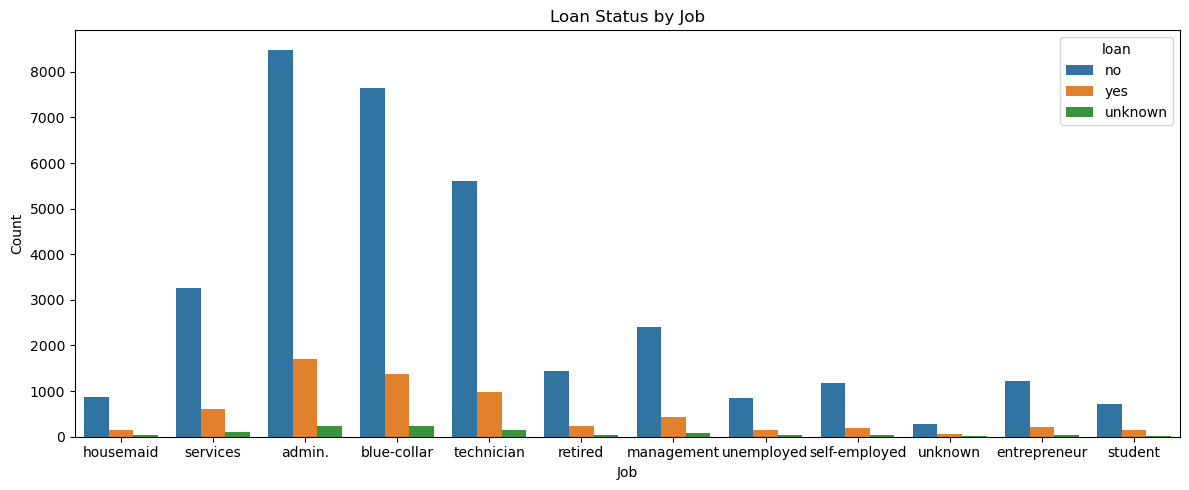

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))

# Plot barplots for Jobs
sns.countplot(data=df, x='job', hue='loan', ax=axes)
axes.set_title('Loan Status by Job')
axes.set_xlabel('Job')
axes.set_ylabel('Count')

plt.tight_layout()
plt.show()


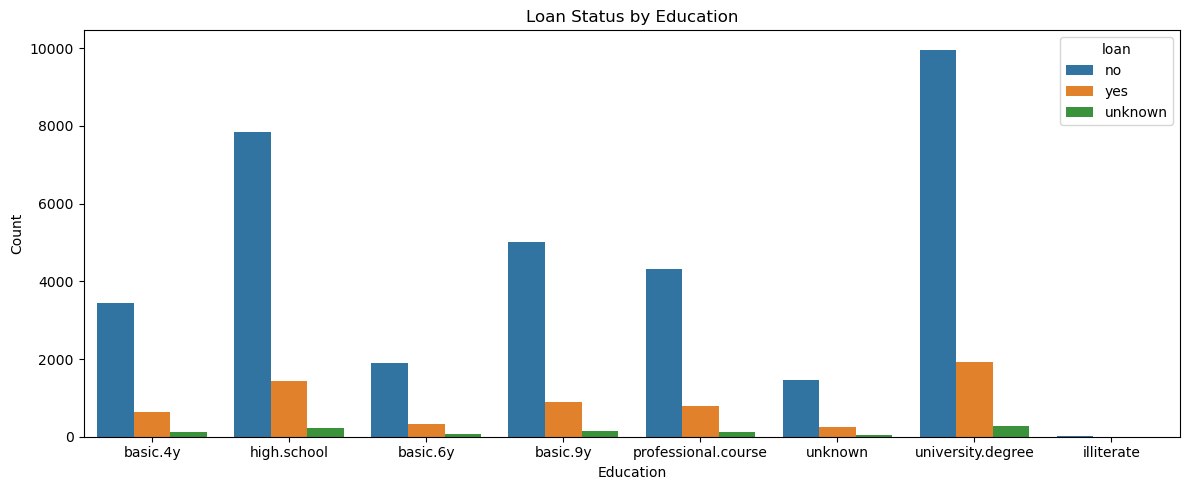

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))

# Plot barplots for Education
sns.countplot(data=df, x='education', hue='loan', ax=axes)
axes.set_title('Loan Status by Education')
axes.set_xlabel('Education')
axes.set_ylabel('Count')

plt.tight_layout()
plt.show()


- In order to calculate distances for K-Means clustering, all features must be in numeric format. solve this issue and then apply scaling

In [23]:
# Observe the inital data
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [24]:
# Convert categorical columns to numeric using one-hot encoding
df = pd.get_dummies(df)


In [25]:
# Observe the data after one-one-hot encoding
df.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,1,0,0,0,0,1,0,1,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,1,0,0,0,0,1,0,1,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,1,0,0,0,0,1,0,1,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,1,0,0,0,0,1,0,1,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,1,0,0,0,0,1,0,1,0


In [26]:
# Select relevant columns for clustering
selected_columns = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Extract the selected columns for clustering
X = df[selected_columns]

In [27]:
# Observe the selected columns of DataFrame
X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0


In [28]:
## We need to standardize the X DataFrame

# Store the column names
column_names = X.columns

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame X with the standardized values and original column names
X_scaled = pd.DataFrame(X_scaled, columns=column_names)


In [29]:
# Observe the selected columns of DataFrame after StandardScaling
X_scaled.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.533034,0.010471,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
1,1.628993,-0.421501,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
2,-0.290186,-0.124520,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
3,-0.002309,-0.413787,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
4,1.533034,0.187888,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168


Use kmeans and fit the model

In [30]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42) 
df['cluster'] = kmeans.fit_predict(X_scaled)

- correlations of each feature with clusters that you assigned.

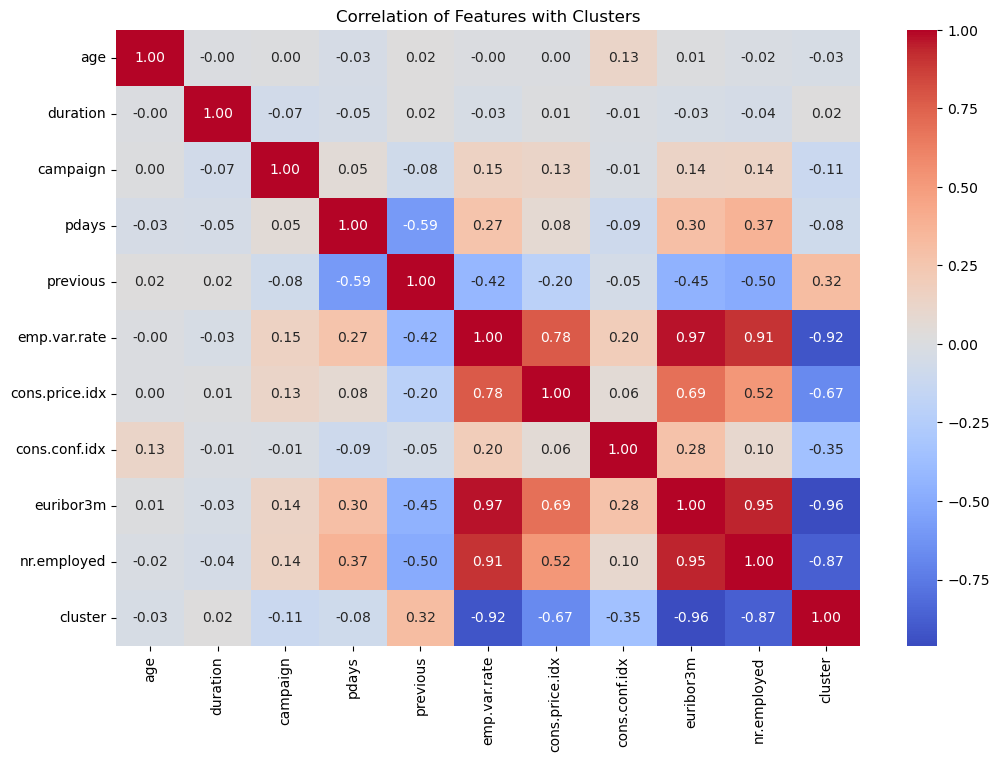

In [31]:
# Check the correlation of each feature with clusters
cluster_corr = df[selected_columns + ['cluster']].corr()

# Visualize the correlation using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Features with Clusters')
plt.show()


- How to find optimal number of clusters (K)?

To find optimal number of clusters, we can use different metrics. I will use three of them in this task, then I will make a conclusion by comparing the optimal number suggested by each metric.

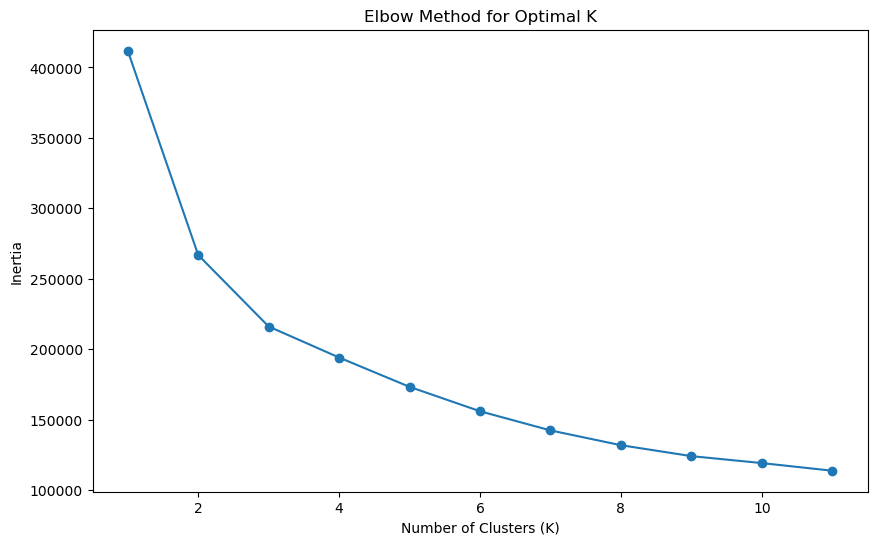

In [32]:
# Evaluate the optimal number of clusters (K) using the Elbow Method
inertia = []
for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 12), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [33]:
from sklearn.metrics import silhouette_score

# Evaluate the optimal number of clusters (K) using Silhouette Score
silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)


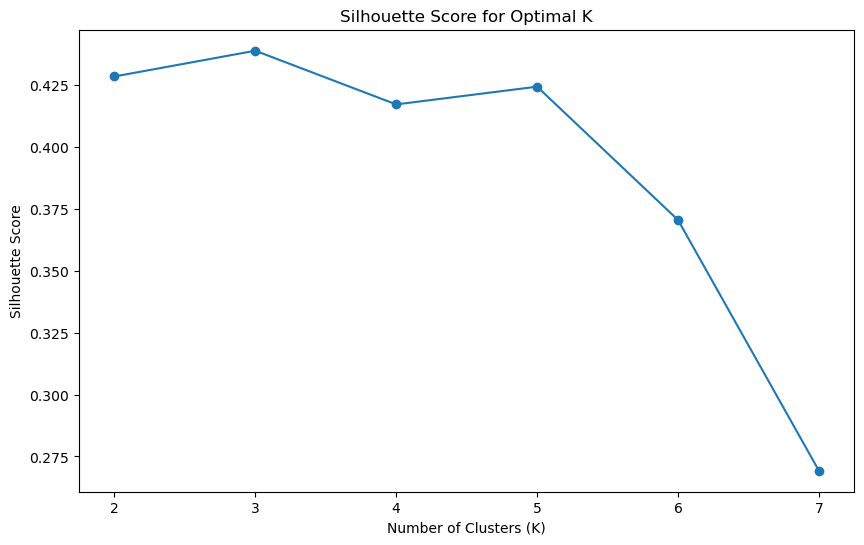

In [34]:
# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 8), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()


In [35]:
from sklearn.metrics import davies_bouldin_score

# Evaluate the optimal number of clusters (K) using Davies-Bouldin Index
davies_bouldin_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    davies_bouldin_idx = davies_bouldin_score(X_scaled, cluster_labels)
    davies_bouldin_scores.append(davies_bouldin_idx)


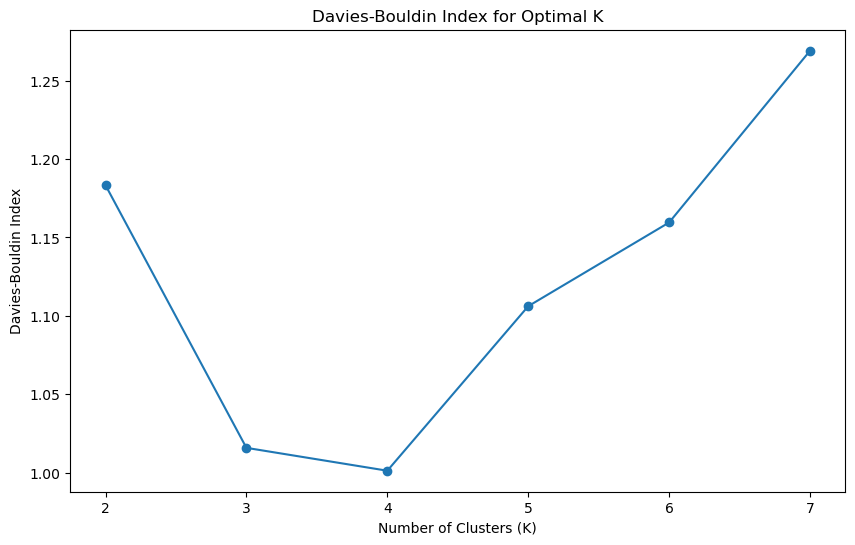

In [36]:
# Plot the Davies-Bouldin Index graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 8), davies_bouldin_scores, marker='o')
plt.title('Davies-Bouldin Index for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.show()


###
$$\Large\textbf{Conclusion}$$

The optimal K-value is 3 according to the `silhouette_score` and `Elbow Method`, while the `davies_bouldin_score` indicates that the optimal K is 4.

So overall, I have decided to take 3 as the optimal K-Value. Which also makes sense with our data.

## DBSCAN (Density-based spatial clustering)

**DBSCAN**, which stands for Density-Based Spatial Clustering of Applications with Noise, is a clustering algorithm used in machine learning and data mining. Unlike k-means, DBSCAN does not require the user to specify the number of clusters beforehand and can identify clusters of arbitrary shapes. It is particularly effective in discovering clusters in data with varying densities.

Here are the main concepts associated with DBSCAN:

**Core Points:**
A data point is considered a core point if there are at least a specified number of data points (minPts) within a certain radius (eps) around it, including itself.

**Border Points:** A data point is a border point if it is within the specified radius of a core point but does not have enough neighbors to be considered a core point itself.

**Noise:** Data points that are neither core points nor border points are considered noise. They do not belong to any cluster.

The DBSCAN algorithm works as follows:

1. **Select a Random Unvisited Data Point:**
Choose a data point that has not been visited.
2. **Expand Cluster:**
If the chosen point is a core point, create a new cluster and expand it by adding all reachable core points (and their neighbors) to the cluster.
3. **Repeat:**
Continue the process until all points have been visited.
The result is a set of clusters, each containing core points that are densely connected. Border points may be part of a cluster but are not as tightly connected as core points. Noise points are not assigned to any cluster.

The DBSCAN algorithm uses two parameters:

**eps (ε):** A distance measure that will be used to locate the points in the neighborhood of any point. For each instance, the algorithm counts how many instances are located within a small distance ε (epsilon) from it. This region is called the instance’s ε-neighborhood.

**minPts:** The minimum number of points (a threshold) clustered together for a region to be considered dense. If an instance has at least min_samples instances in its ε-neighborhood (including itself), then it is considered a core instance. In other words, core instances are those that are located in dense regions. All instances in the neighborhood of a core instance belong to the same cluster. This neighborhood may include other core instances; therefore, a long sequence of neighboring core instances forms a single cluster.

Any instance that is not a core instance and does not have one in its neighborhood is considered an anomaly.

To check out more, please visit [this](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/) online visualisation tool.

## <font color="red">**Question 3**</font>
For a real world example, we will use **Wholesale customers dataset**. The data set refers to clients of a wholesale distributor. It includes the annual spending in monetary units (m.u.) on diverse product categories. It can be downloaded from [here](https://archive.ics.uci.edu/dataset/292/wholesale+customers).


Attribute Information:

1. **FRESH:** annual spending (m.u.) on fresh products (Continuous);
2. **MILK:** annual spending (m.u.) on milk products (Continuous);
3. **GROCERY:** annual spending (m.u.)on grocery products (Continuous);
4. **FROZEN:** annual spending (m.u.)on frozen products (Continuous)
5. **DETERGENTS_PAPER:** annual spending (m.u.) on detergents and paper products (Continuous)
6. **DELICATESSEN:** annual spending (m.u.)on and delicatessen products (Continuous);
7. **CHANNEL:** customers  Channel - Horeca (Hotel/Restaurant/CafÃ©) or Retail channel (Nominal)
8. **REGION:** customers  Region Lisnon, Oporto or Other (Nominal)


- Do exploratory data analysis and preprocessing


In [37]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [38]:
# Load the Wholesale customers dataset
wholesale_data = pd.read_csv("Wholesale customers data.csv")


In [39]:
# Display basic information about the dataset
print(wholesale_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn plots
sns.set(style="ticks")

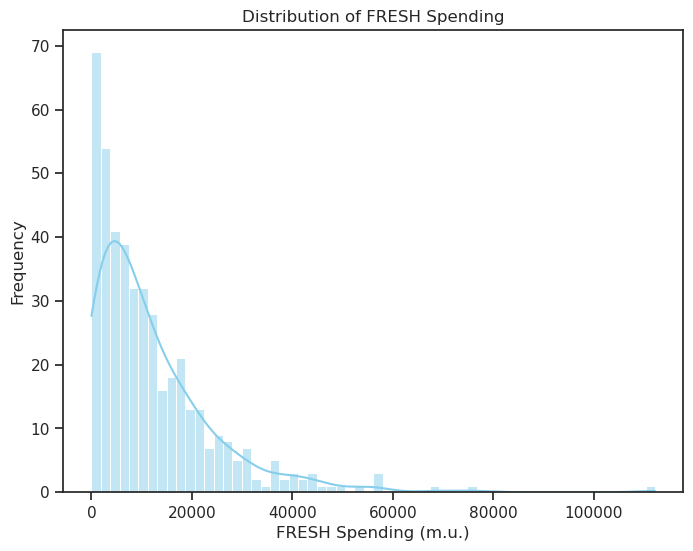

In [41]:
# Plot distribution for 'FRESH'
plt.figure(figsize=(8, 6))
sns.histplot(wholesale_data['Fresh'], bins=60, kde=True, color='skyblue')
plt.title('Distribution of FRESH Spending')
plt.xlabel('FRESH Spending (m.u.)')
plt.ylabel('Frequency')
plt.show()

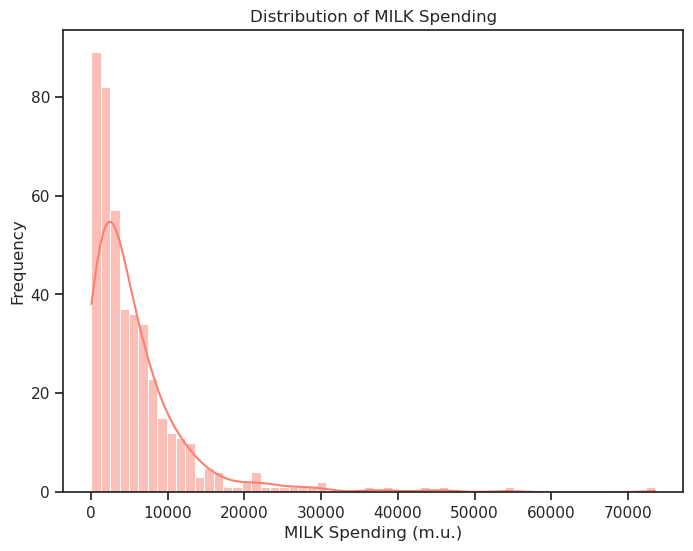

In [42]:
# Plot distribution for 'Milk'
plt.figure(figsize=(8, 6))
sns.histplot(wholesale_data['Milk'], bins=60, kde=True, color='salmon')
plt.title('Distribution of MILK Spending')
plt.xlabel('MILK Spending (m.u.)')
plt.ylabel('Frequency')
plt.show()

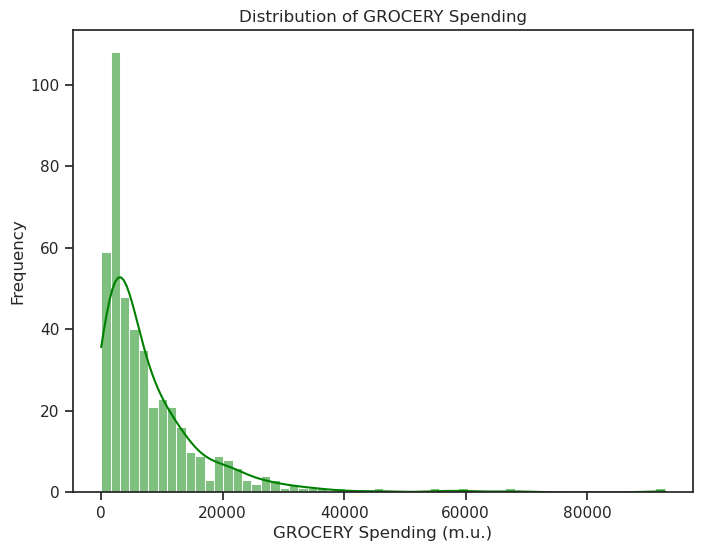

In [43]:
# Plot distribution for 'GROCERY'
plt.figure(figsize=(8, 6))
sns.histplot(wholesale_data['Grocery'], bins=60, kde=True, color='green')
plt.title('Distribution of GROCERY Spending')
plt.xlabel('GROCERY Spending (m.u.)')
plt.ylabel('Frequency')
plt.show()

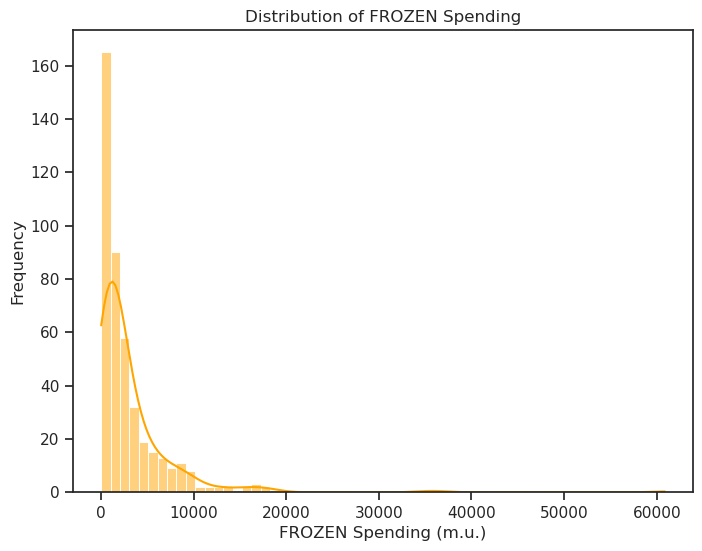

In [44]:
# Plot distribution for 'FROZEN'
plt.figure(figsize=(8, 6))
sns.histplot(wholesale_data['Frozen'], bins=60, kde=True, color='orange')
plt.title('Distribution of FROZEN Spending')
plt.xlabel('FROZEN Spending (m.u.)')
plt.ylabel('Frequency')
plt.show()

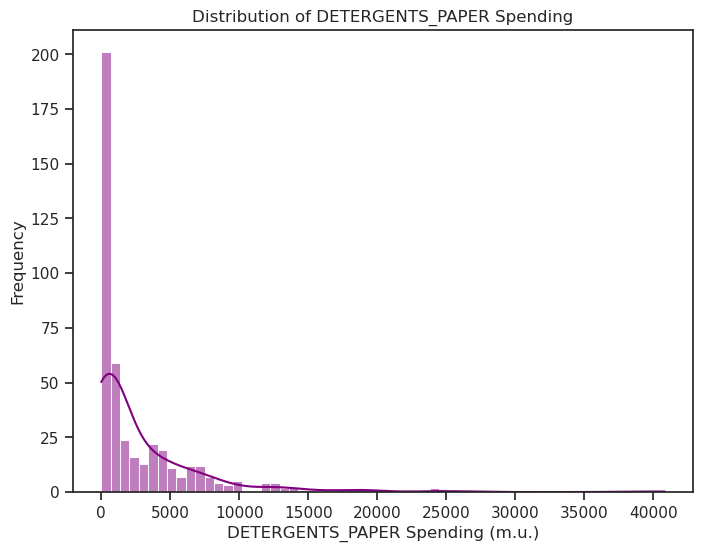

In [45]:
# Plot distribution for 'DETERGENTS_PAPER'
plt.figure(figsize=(8, 6))
sns.histplot(wholesale_data['Detergents_Paper'], bins=60, kde=True, color='purple')
plt.title('Distribution of DETERGENTS_PAPER Spending')
plt.xlabel('DETERGENTS_PAPER Spending (m.u.)')
plt.ylabel('Frequency')
plt.show()

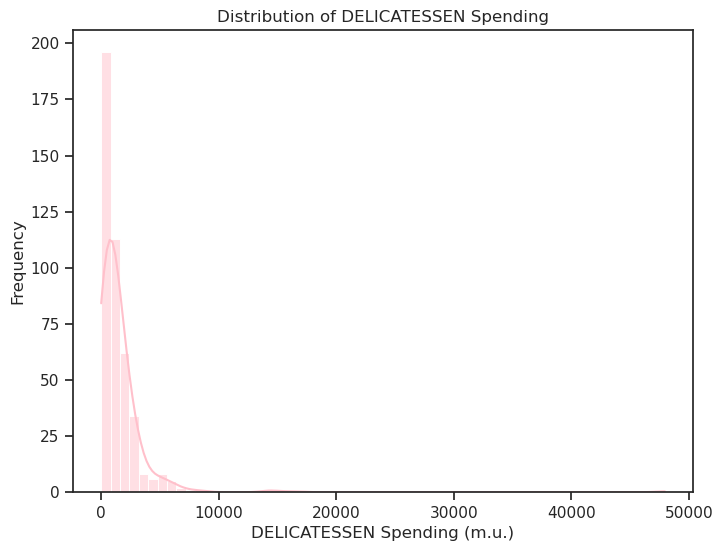

In [46]:
# Plot distribution for 'DELICATESSEN'
plt.figure(figsize=(8, 6))
sns.histplot(wholesale_data['Delicassen'], bins=60, kde=True, color='pink')
plt.title('Distribution of DELICATESSEN Spending')
plt.xlabel('DELICATESSEN Spending (m.u.)')
plt.ylabel('Frequency')
plt.show()


In [47]:
# Display the updated dataset
print(wholesale_data.head())


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


- Showing the relation between *MILK* and *GROCERY* spending

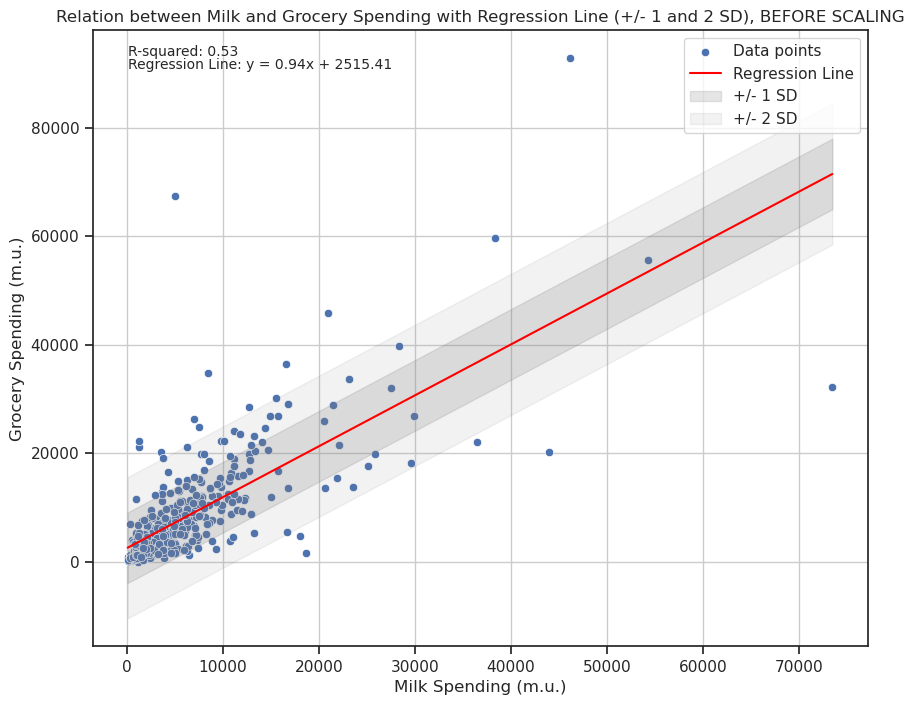

In [48]:
import numpy as np
from scipy.stats import linregress

# Fit a linear regression line
slope, intercept, r_value, p_value, std_err = linregress(wholesale_data['Milk'], wholesale_data['Grocery'])
line = lambda x: slope * x + intercept

# Calculate residuals
residuals = wholesale_data['Grocery'] - line(wholesale_data['Milk'])

# Calculate standard deviation of the residuals
residuals_std = np.std(residuals)

# Calculate R-squared value
r_squared = r_value ** 2

# Plot the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Milk', y='Grocery', data=wholesale_data, label='Data points')

# Plot the regression line
x_values = np.linspace(min(wholesale_data['Milk']), max(wholesale_data['Milk']), 100)
plt.plot(x_values, line(x_values), color='red', label='Regression Line')

# Calculate upper and lower bounds for the area around the regression line
upper_bound_1sd = line(x_values) + residuals_std
lower_bound_1sd = line(x_values) - residuals_std
upper_bound_2sd = line(x_values) + 2 * residuals_std
lower_bound_2sd = line(x_values) - 2 * residuals_std

# Fill the area between upper and lower bounds for +/- 1 SD
plt.fill_between(x_values, upper_bound_1sd, lower_bound_1sd, color='gray', alpha=0.2, label='+/- 1 SD')

# Fill the area between upper and lower bounds for +/- 2 SD with a lighter shade
plt.fill_between(x_values, upper_bound_2sd, lower_bound_2sd, color='gray', alpha=0.1, label='+/- 2 SD')

# Add regression line equation with proper formatting
equation_text = f'Regression Line: y = {slope:.2f}x + {intercept:.2f}' if intercept >= 0 else f'Regression Line: y = {slope:.2f}x - {-intercept:.2f}'
plt.text(min(wholesale_data['Milk']), max(wholesale_data['Grocery']) - 20, equation_text, fontsize=10, verticalalignment='top')

# Add R-squared value with adjusted position
r_squared_text = f'R-squared: {r_squared:.2f}'
plt.text(min(wholesale_data['Milk']), max(wholesale_data['Grocery']) - 40, r_squared_text, fontsize=10, verticalalignment='bottom')

# Add labels, title, and grid
plt.title('Relation between Milk and Grocery Spending with Regression Line (+/- 1 and 2 SD), BEFORE SCALING')
plt.xlabel('Milk Spending (m.u.)')
plt.ylabel('Grocery Spending (m.u.)')
plt.grid(True)

# Add legend
plt.legend()

# Show the plot
plt.show()


In [49]:
from sklearn.preprocessing import StandardScaler

# Extracting numerical columns from the dataset
numerical_columns = wholesale_data.select_dtypes(include=['int64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply Standard Scaler on each column using a for loop
for column in numerical_columns:
    # Reshape the column to a 2D array before scaling
    column_data = wholesale_data[column].values.reshape(-1, 1)
    
    # Fit and transform the data with Standard Scaler
    scaled_data = scaler.fit_transform(column_data)
    
    # Update the column in the dataset with the scaled data
    wholesale_data[column] = scaled_data.flatten()

# Display the updated dataset
print(wholesale_data.head())


    Channel    Region     Fresh      Milk   Grocery    Frozen  \
0  1.448652  0.590668  0.052933  0.523568 -0.041115 -0.589367   
1  1.448652  0.590668 -0.391302  0.544458  0.170318 -0.270136   
2  1.448652  0.590668 -0.447029  0.408538 -0.028157 -0.137536   
3 -0.690297  0.590668  0.100111 -0.624020 -0.392977  0.687144   
4  1.448652  0.590668  0.840239 -0.052396 -0.079356  0.173859   

   Detergents_Paper  Delicassen  
0         -0.043569   -0.066339  
1          0.086407    0.089151  
2          0.133232    2.243293  
3         -0.498588    0.093411  
4         -0.231918    1.299347  


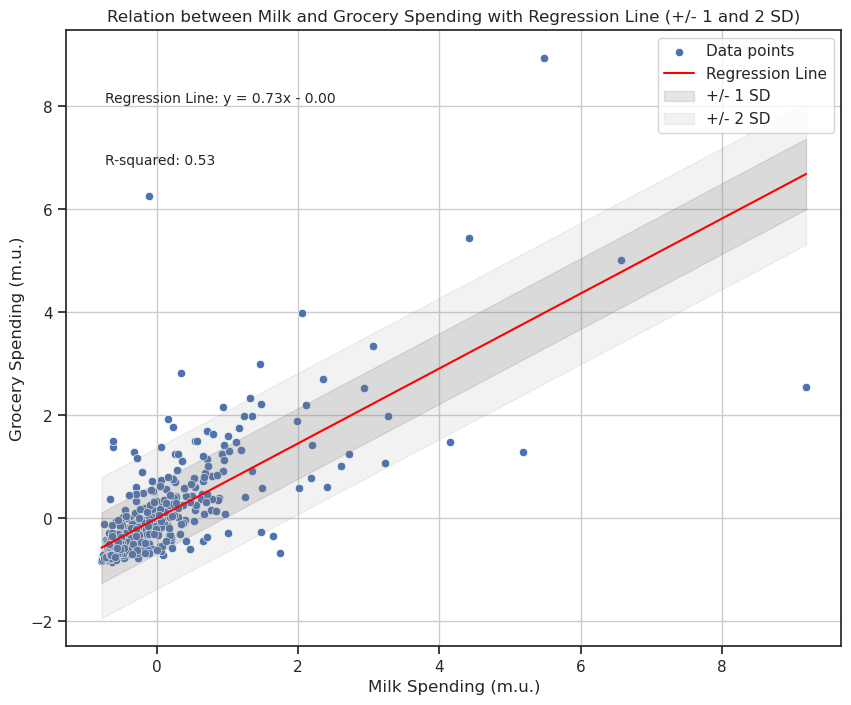

In [50]:
import numpy as np
from scipy.stats import linregress

# Fit a linear regression line
slope, intercept, r_value, p_value, std_err = linregress(wholesale_data['Milk'], wholesale_data['Grocery'])
line = lambda x: slope * x + intercept

# Calculate residuals
residuals = wholesale_data['Grocery'] - line(wholesale_data['Milk'])

# Calculate standard deviation of the residuals
residuals_std = np.std(residuals)

# Calculate R-squared value
r_squared = r_value ** 2

# Plot the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Milk', y='Grocery', data=wholesale_data, label='Data points')

# Plot the regression line
x_values = np.linspace(min(wholesale_data['Milk']), max(wholesale_data['Milk']), 100)
plt.plot(x_values, line(x_values), color='red', label='Regression Line')

# Calculate upper and lower bounds for the area around the regression line
upper_bound_1sd = line(x_values) + residuals_std
lower_bound_1sd = line(x_values) - residuals_std
upper_bound_2sd = line(x_values) + 2 * residuals_std
lower_bound_2sd = line(x_values) - 2 * residuals_std

# Fill the area between upper and lower bounds for +/- 1 SD
plt.fill_between(x_values, upper_bound_1sd, lower_bound_1sd, color='gray', alpha=0.2, label='+/- 1 SD')

# Fill the area between upper and lower bounds for +/- 2 SD with a lighter shade
plt.fill_between(x_values, upper_bound_2sd, lower_bound_2sd, color='gray', alpha=0.1, label='+/- 2 SD')

# Add regression line equation with proper formatting
equation_text = f'Regression Line: y = {slope:.2f}x + {intercept:.2f}' if intercept >= 0 else f'Regression Line: y = {slope:.2f}x - {-intercept:.2f}'
plt.text(0.05, 0.9, equation_text, fontsize=10, verticalalignment='top', horizontalalignment='left', transform=plt.gca().transAxes)

# Add R-squared value with adjusted position
r_squared_text = f'R-squared: {r_squared:.2f}'
plt.text(0.05, 0.8, r_squared_text, fontsize=10, verticalalignment='top', horizontalalignment='left', transform=plt.gca().transAxes)

# Add labels, title, and grid
plt.title('Relation between Milk and Grocery Spending with Regression Line (+/- 1 and 2 SD)')
plt.xlabel('Milk Spending (m.u.)')
plt.ylabel('Grocery Spending (m.u.)')
plt.grid(True)

# Add legend
plt.legend()

# Show the plot
plt.show()


- Create a variety of models testing different epsilon values.

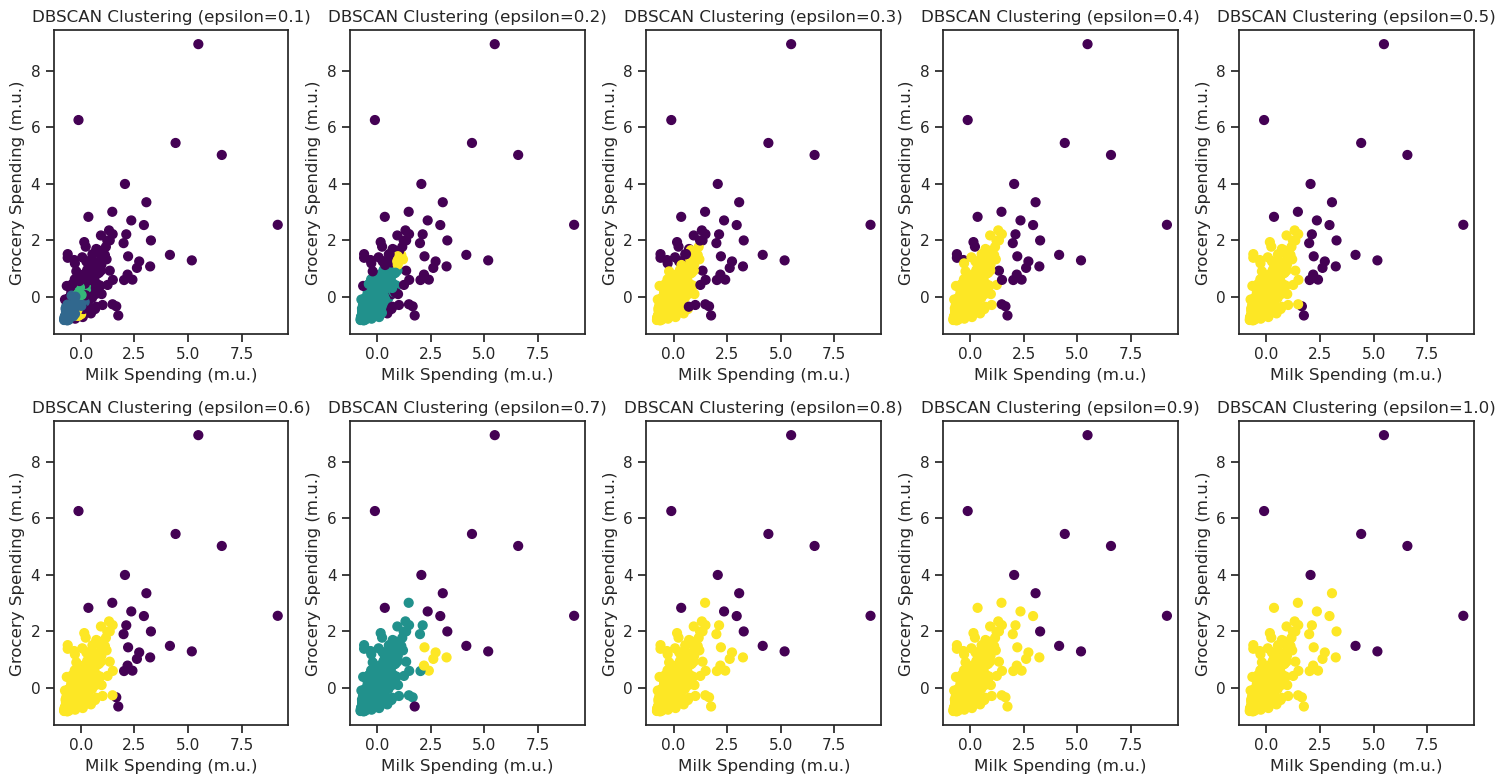

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN

# Create models testing different epsilon values
epsilon_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Plot each clustering
plt.figure(figsize=(15, 8))
for i, epsilon in enumerate(epsilon_values, 1):
    dbscan_model = DBSCAN(eps=epsilon, min_samples=6)
    dbscan_labels = dbscan_model.fit_predict(wholesale_data[['Milk', 'Grocery']])
    
    # Visualize clustering
    plt.subplot(2, 5, i)
    plt.scatter(wholesale_data['Milk'], wholesale_data['Grocery'], c=dbscan_labels, cmap='viridis', s=40)
    plt.title(f'DBSCAN Clustering (epsilon={epsilon})')
    plt.xlabel('Milk Spending (m.u.)')
    plt.ylabel('Grocery Spending (m.u.)')

plt.tight_layout()
plt.show()


- Based on the plot that you had from the last part, retrain a DBSCAN model with a reasonable epsilon value

Based on the plots, I think `epsilon=0.5` is the appropriate value for the DBSCAN, when `min_samples=6`.

In [52]:
dbscan_model_final = DBSCAN(eps=0.6, min_samples=6)
dbscan_labels_final = dbscan_model_final.fit_predict(wholesale_data[['Milk', 'Grocery']])

## Image segmentation


Image segmentation is a computer vision task that involves dividing an image into meaningful and semantically coherent regions or segments. The goal is to partition an image into regions that share similar visual characteristics, such as color, texture, intensity, or other features. Each segment typically represents a distinct object or region of interest within the image.

## <font color="red">**Question 4**</font>
In this question, you are supposed to segmente an image using KMeans clustering.


In [53]:
#Libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_sample_image
#load_sample_image dataset from scikit learn consists of numpy array of a single sample image

#Data plotting and visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix

- Load a sample flower image from load_sample_image scikit learn dataset and show the image


In [54]:
flower = load_sample_image("flower.jpg")

- Get shape, scale, reshape

In [55]:
# Get shape, scale, reshape
flower_shape = flower.shape
flower_scaled = flower / 255.0  # Scale pixel values to the range [0, 1]
flower_reshaped = flower_scaled.reshape((-1, 3))

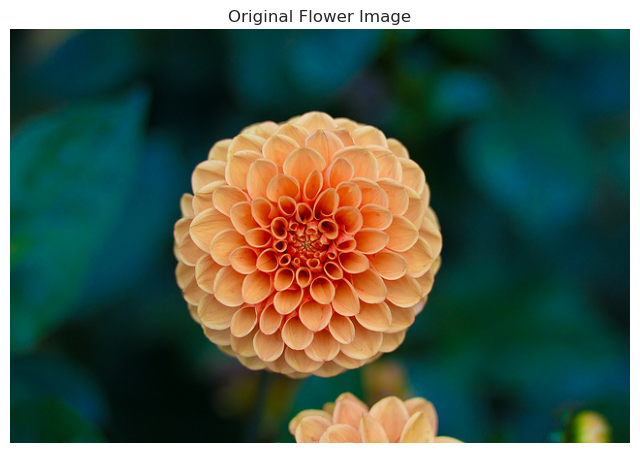

In [56]:
# Visualize the original image
plt.figure(figsize=(8, 8))
plt.imshow(flower)
plt.title('Original Flower Image')
plt.axis('off')
plt.show()


- Use KMeans clustering and get the different colored images


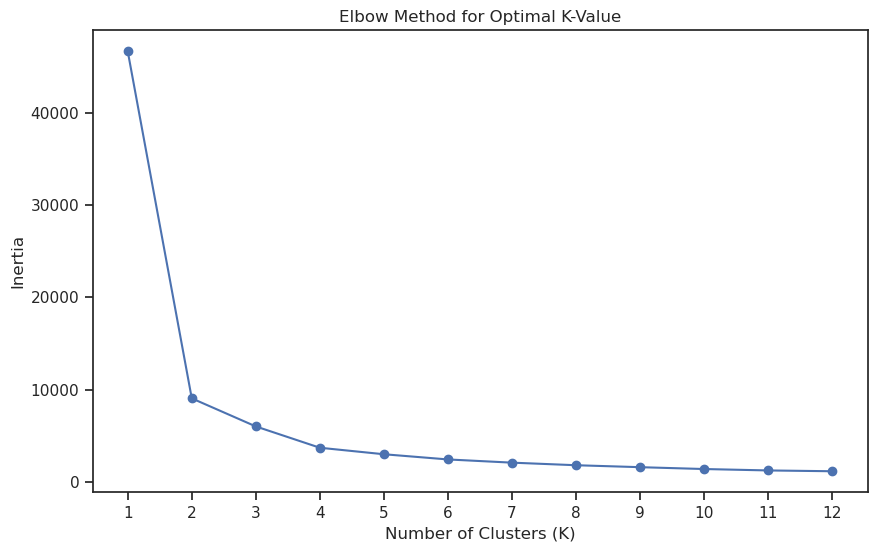

In [57]:
# Elbow method to find the ideal K-value
inertia_values = []
k_values = range(1, 13)  # Testing K-values from 1 to 12

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(flower_reshaped)
    inertia_values.append(kmeans.inertia_)

# Plotting the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal K-Value')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()


From the Elbow method, I think 4 is an appropriate number for the number of clusters.

In [58]:
# Use KMeans clustering and get different colored images
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(flower_reshaped)
flower_segmented = kmeans.cluster_centers_[kmeans.labels_].reshape(flower_shape)

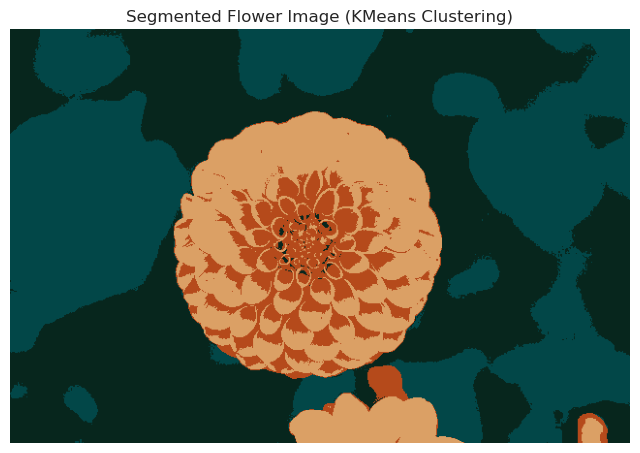

In [59]:
# Visualize the segmented image
plt.figure(figsize=(8, 8))
plt.imshow(flower_segmented)
plt.title('Segmented Flower Image (KMeans Clustering)')
plt.axis('off')
plt.show()


Retry the code with K=12, which will obivously overfit.

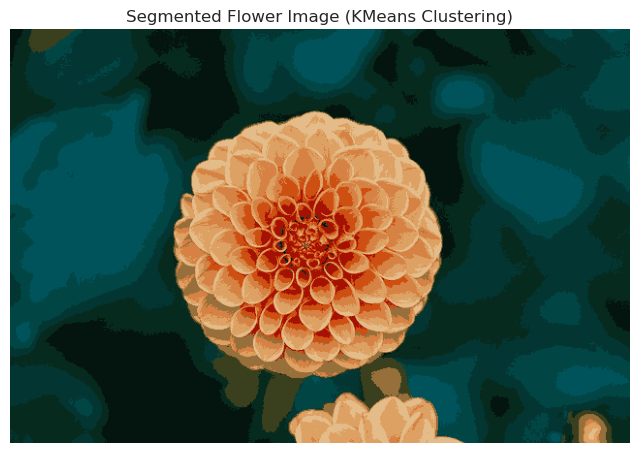

In [60]:
# Use KMeans clustering and get different colored images
kmeans = KMeans(n_clusters=12, random_state=42)
kmeans.fit(flower_reshaped)
flower_segmented = kmeans.cluster_centers_[kmeans.labels_].reshape(flower_shape)

# Visualize the segmented image
plt.figure(figsize=(8, 8))
plt.imshow(flower_segmented)
plt.title('Segmented Flower Image (KMeans Clustering)')
plt.axis('off')
plt.show()


In [61]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


## Gaussian Mixture Model

**Gaussian Mixture Model** (GMM) is a probabilistic model that represents a mixture of multiple Gaussian (normal) distributions. Each component Gaussian distribution in the mixture represents a cluster or a subpopulation within the overall dataset. GMMs are commonly used for modeling complex probability distributions and are frequently applied in the field of machine learning, particularly in unsupervised learning tasks such as clustering and density estimation.

## <font color="red">**Question 5**</font>
To deal with GMM, we will use **CC GENERAL** dataset.

Following is the Data Dictionary for Credit Card dataset :

- **CUST_ID** : Identification of Credit Card holder (Categorical)
- **BALANCE** : Balance amount left in their account to make purchases
- **BALANCE_FREQUENCY** : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
- **PURCHASES** : Amount of purchases made from account
- **ONEOFF_PURCHASES** : Maximum purchase amount done in one-go
- **INSTALLMENTS_PURCHASES** : Amount of purchase done in installment
- **CASH_ADVANCE** : Cash in advance given by the user
- **PURCHASES_FREQUENCY** : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- **ONEOFFPURCHASESFREQUENCY** : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
- **CASHADVANCEFREQUENCY** : How frequently the cash in advance being paid
- **CASHADVANCETRX** : Number of Transactions made with "Cash in Advanced"
- **PURCHASES_TRX** : Numbe of purchase transactions made
- **CREDIT_LIMIT** : Limit of Credit Card for user
- **PAYMENTS** : Amount of Payment done by user
- **MINIMUM_PAYMENTS** : Minimum amount of payments made by user
- **PRCFULLPAYMENT** : Percent of full payment paid by user
- **TENURE** : Tenure of credit card service for user


In [62]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn import metrics

- Load dataset

In [63]:
# Load dataset
credit_card_df = pd.read_csv('CC GENERAL 2.csv')


In [64]:
credit_card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [65]:
# Drop the CUST_ID column as it is categorical and not needed for clustering
credit_card_df = credit_card_df.drop('CUST_ID', axis=1)

In [66]:
# Convert all numerical columns to float64
numerical_cols = credit_card_df.select_dtypes(include=['int64', 'float64']).columns
credit_card_df[numerical_cols] = credit_card_df[numerical_cols].astype('float64')

In [67]:
# Handle missing values (replace NaN with mean)
credit_card_df.fillna(credit_card_df.mean(), inplace=True)

- Standardize data, Normalize and Reduce the dimensions of the data

In [68]:
# Standardize data, Normalize, and Reduce dimensions using PCA
scaler = StandardScaler()
credit_card_scaled = scaler.fit_transform(credit_card_df)

# Normalize the data
credit_card_normalized = normalize(credit_card_scaled)

# Reduce dimensions using PCA
pca = PCA(n_components=3)
credit_card_pca = pca.fit_transform(credit_card_normalized)

In [69]:
# Normalize the data
credit_card_normalized = normalize(credit_card_scaled)

In [70]:
# Reduce dimensions using PCA
pca = PCA(n_components=2)
credit_card_pca = pca.fit_transform(credit_card_normalized)

- Use Gaussian Mixture Model

In [71]:
# Use Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(credit_card_pca)
labels = gmm.predict(credit_card_pca)

- Visualize the clustering and analyse

In [72]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import jensenshannon

# Initialize parameters
n_components_range = range(2, 8)
n_iterations = 5

# Results storage
silhouette_scores = []
gmm_distances = []
bic_scores = []

In [73]:
# Silhouette Score Analysis
for n_components in n_components_range:
    silhouette_vals = []
    for _ in range(n_iterations):
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        labels = gmm.fit_predict(credit_card_pca)
        silhouette_vals.append(silhouette_score(credit_card_pca, labels))
    silhouette_scores.append((np.mean(silhouette_vals), np.std(silhouette_vals)))


In [74]:
# GMM Distance Analysis
half_data_size = len(credit_card_pca) // 2
data_set_1 = credit_card_pca[:half_data_size]
data_set_2 = credit_card_pca[half_data_size:]

for n_components in n_components_range:
    distances = []
    for _ in range(n_iterations):
        gmm_1 = GaussianMixture(n_components=n_components, random_state=42)
        gmm_2 = GaussianMixture(n_components=n_components, random_state=42)
        labels_1 = gmm_1.fit_predict(data_set_1)
        labels_2 = gmm_2.fit_predict(data_set_2)
        distances.append(jensenshannon(gmm_1.weights_, gmm_2.weights_))
    gmm_distances.append((np.mean(distances), np.std(distances)))

In [75]:
# BIC Analysis
for n_components in n_components_range:
    bic_vals = []
    for _ in range(n_iterations):
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(credit_card_pca)
        bic_vals.append(gmm.bic(credit_card_pca))
    bic_scores.append((np.mean(bic_vals), np.std(bic_vals)))

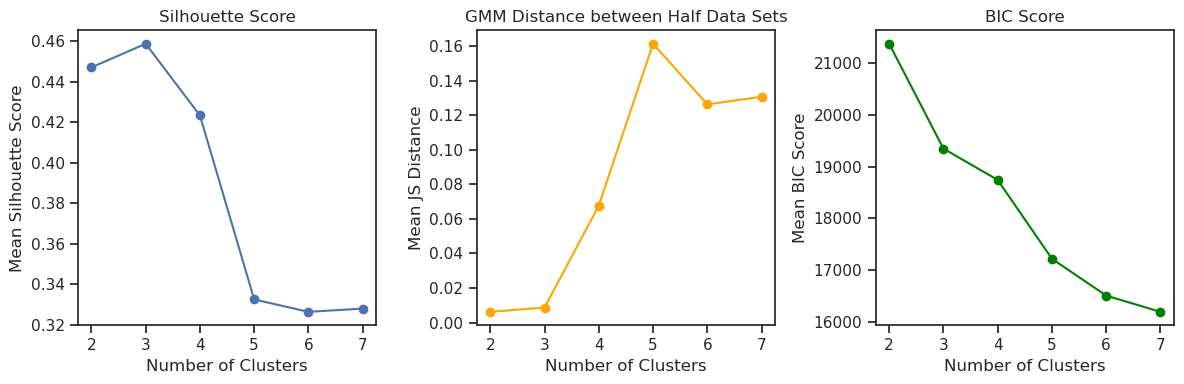

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Extract results from the analysis
silhouette_scores_mean, silhouette_scores_std = zip(*silhouette_scores)
gmm_distances_mean, gmm_distances_std = zip(*gmm_distances)
bic_scores_mean, bic_scores_std = zip(*bic_scores)

# Plot Silhouette Score
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.errorbar(list(n_components_range), silhouette_scores_mean, yerr=silhouette_scores_std, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Mean Silhouette Score')

# Plot GMM Distance
plt.subplot(1, 3, 2)
plt.errorbar(list(n_components_range), gmm_distances_mean, yerr=gmm_distances_std, marker='o', color='orange')
plt.title('GMM Distance between Half Data Sets')
plt.xlabel('Number of Clusters')
plt.ylabel('Mean JS Distance')

# Plot BIC Score
plt.subplot(1, 3, 3)
plt.errorbar(list(n_components_range), bic_scores_mean, yerr=bic_scores_std, marker='o', color='green')
plt.title('BIC Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Mean BIC Score')

plt.tight_layout()
plt.show()


From these three plots, we can find out that `n_components=5` is the optimal number of clusters, without overfitting for this model.

In [77]:
# Use Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(credit_card_pca)
labels = gmm.predict(credit_card_pca)

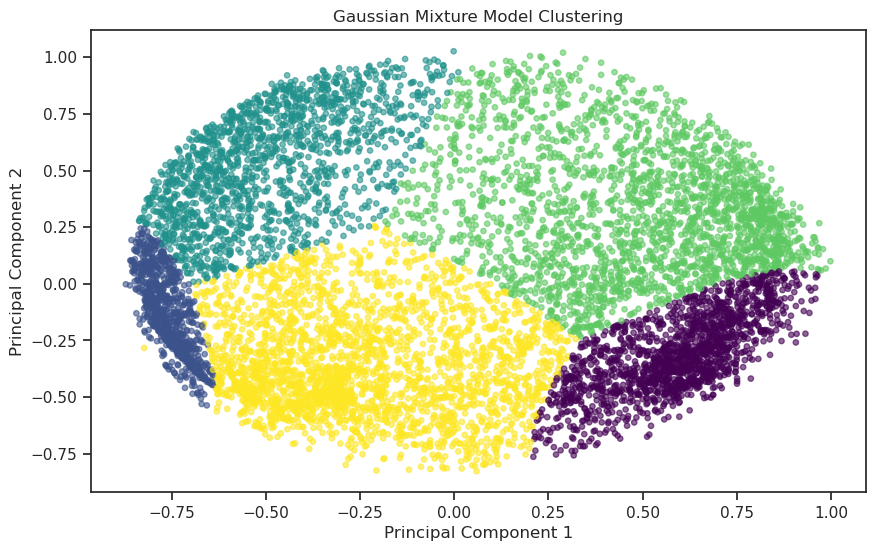

In [78]:
# Visualize the clustering
plt.figure(figsize=(10, 6))
plt.scatter(credit_card_pca[:, 0], credit_card_pca[:, 1], c=labels, cmap='viridis', s=15, alpha=0.6)
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [79]:
def feature_importance_in_clustering(data):
    """
    Calculates the importance of each feature for clustering by analyzing its impact
    on the silhouette scores.
    
    The silhouette score is a measure of how similar an object is to its own cluster 
    (cohesion) compared to other clusters (separation). The silhouette score ranges 
    from -1 to 1, where a high value indicates that the object is well matched to 
    its own cluster and poorly matched to neighboring clusters.

    Parameters:
    - data (pd.DataFrame): The input data with features used for clustering.

    Returns:
    - pd.DataFrame: A data frame containing the normalized importance of each feature.
    """
    
    # Standardize the data for uniform scales across all features
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # Initialize and fit a Gaussian Mixture Model for clustering
    gmm = GaussianMixture(n_components=5, random_state=42)
    gmm.fit(data_scaled)
    cluster_labels = gmm.predict(data_scaled)

    # Calculate the silhouette scores for each sample in the dataset
    sample_silhouette_values = silhouette_samples(data_scaled, cluster_labels)

    feature_importances = []
    # Iterate over each feature to calculate their respective importance
    for feature in data.columns:
        # Obtain the array of values for the current feature
        feature_array = data_scaled[:, data.columns == feature]
        # Compute the average silhouette score where the feature's value is above its mean
        feature_importance = np.mean([
            silhouette_values for silhouette_values, feature_value
            in zip(sample_silhouette_values, feature_array)
            if feature_value > feature_array.mean()
        ])
        feature_importances.append(feature_importance)
    
    # Create a DataFrame to hold each feature's importance score
    importance_df = pd.DataFrame(feature_importances, index=data.columns, columns=['Importance'])

    # Normalize the importance scores to sum up to 1
    importance_df['Importance'] /= np.sum(importance_df['Importance'])

    return importance_df

In [80]:

def plot_feature_importance_in_clustering(importance_df):
    """
    Plots the normalized importance of each feature in the clustering task.
    
    Parameters:
    - importance_df (pd.DataFrame): Data frame containing the normalized importances of the features.

    This function will display a bar plot showing the contribution of each feature as calculated from their silhouette scores.
    """
    
    # Plot the normalized feature importance
    importance_df.plot(kind='bar', figsize=(14, 7), color='skyblue')
    plt.title("Feature Importance in Clustering")
    plt.ylabel('Mean Silhouette Coefficient')
    plt.xlabel('Features')
    # Place the legend outside of the plot area
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.show()


In [81]:
credit_card_clustering_importance = feature_importance_in_clustering(credit_card_df)
plot_feature_importance_in_clustering(credit_card_clustering_importance)

NameError: name 'silhouette_samples' is not defined

I don't think there is any need for train_test_split in this tak, but since the related library was imported in the question, I will rewrite the code to see whether my model is working good at the test set or not.

In [ ]:
# Load dataset
credit_card_df = pd.read_csv('CC GENERAL 2.csv')

# Preprocessing steps
credit_card_df = credit_card_df.drop('CUST_ID', axis=1)
numerical_cols = credit_card_df.select_dtypes(include=['int64', 'float64']).columns
credit_card_df[numerical_cols] = credit_card_df[numerical_cols].astype('float64')
credit_card_df.fillna(credit_card_df.mean(), inplace=True)

# Standardize and normalize the data
scaler = StandardScaler()
credit_card_scaled = scaler.fit_transform(credit_card_df)
credit_card_normalized = normalize(credit_card_scaled)

# Applying PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
credit_card_pca = pca.fit_transform(credit_card_normalized)

# Split the data into training and test sets
X_train, X_test = train_test_split(credit_card_pca, test_size=0.3, random_state=42)

# Fit a Gaussian Mixture Model on the training data
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_train)
train_labels = gmm.predict(X_train)
test_labels = gmm.predict(X_test)

Train Silhouette Score: 0.33318182327251544
Test Silhouette Score: 0.34495392717553025


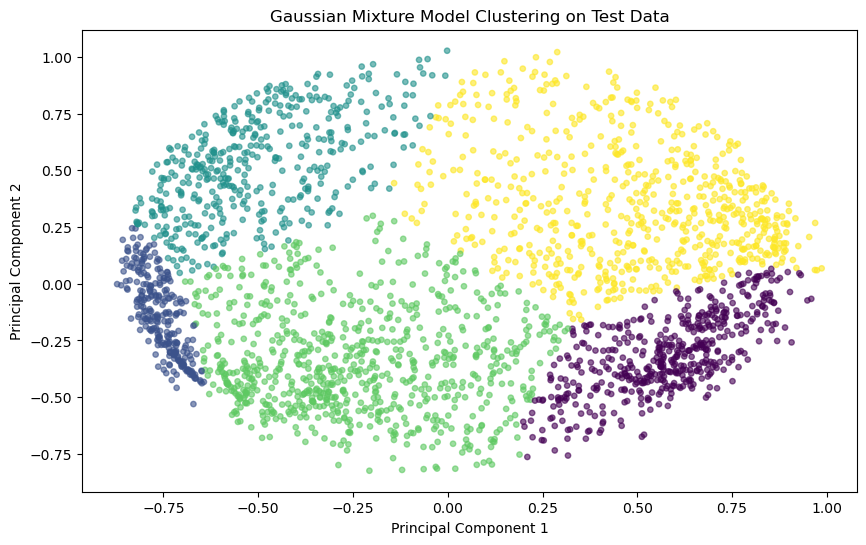

In [ ]:
# Evaluate the model's performance on the training and test sets 
# using the silhouette score
train_silhouette = silhouette_score(X_train, train_labels)
test_silhouette = silhouette_score(X_test, test_labels)

print(f'Train Silhouette Score: {train_silhouette}')
print(f'Test Silhouette Score: {test_silhouette}')

In [ ]:
# Visualize the clustering on the test data
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_labels, cmap='viridis', s=15, alpha=0.6)
plt.title('Gaussian Mixture Model Clustering on Test Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()